# Phase 1: Domain Research + EDA + Baseline — Fraud Detection System
**Date:** 2026-04-27  
**Researcher:** Anthony Rodrigues  

## Objective
Establish the dataset, perform thorough EDA, and build baseline models for credit card fraud detection.
We use the Sparkov-generated credit card transaction dataset (Kartik2112) with **real feature names** — 
merchant, category, amount, location, timestamps — enabling meaningful domain feature engineering.

## Primary Metric: AUPRC (Area Under Precision-Recall Curve)
**Justification:** For fraud detection with extreme class imbalance (~0.5% fraud rate),
ROC-AUC is misleadingly optimistic because TNR is always near 1.0. AUPRC directly measures
the precision-recall tradeoff that matters operationally: can we catch fraud without drowning
investigators in false positives? This is the standard metric used in:
- Davis & Goadrich (2006), "The relationship between PR and ROC curves"
- Kaggle fraud detection competitions (IEEE-CIS used AUC but top solutions reported AUPRC)
- Industry fraud systems (Stripe, PayPal) where precision at high recall is the key operational metric

**Secondary metrics:** F1-score, Precision@95%Recall, ROC-AUC, Recall@5%FPR

## Research & References
1. **Frontiers in AI (2025)** — Traditional and deep learning models with class imbalance mitigation: 
   XGBoost and Random Forest consistently top tabular fraud benchmarks
2. **MLPills Issue #101** — SMOTE's Limitations in Modern ML: SMOTE blends unrelated fraud types,
   causing models to learn from synthetic examples that never occurred; cost-sensitive learning
   and threshold tuning are preferred alternatives
3. **Stripe Engineering** — Domain features (velocity, geographic anomaly, merchant risk) 
   outperform raw transaction features alone; building the right features matters more than algorithm choice

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_curve, average_precision_score, f1_score,
    precision_score, recall_score, RocCurveDisplay, PrecisionRecallDisplay
)
import json
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
print('All imports loaded successfully')

All imports loaded successfully


In [2]:
df = pd.read_csv('../data/raw/fraud_transactions.csv')
print(f'Dataset shape: {df.shape}')
print(f'\nColumns ({len(df.columns)}):')
for col in df.columns:
    print(f'  {col}: {df[col].dtype} — {df[col].nunique()} unique, {df[col].isna().sum()} missing')
print(f'\nMemory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')

Dataset shape: (1048575, 23)

Columns (23):
  Unnamed: 0: int64 — 1048575 unique, 0 missing


  trans_date_trans_time: object — 476595 unique, 0 missing
  cc_num: float64 — 943 unique, 0 missing
  merchant: object — 693 unique, 0 missing
  category: object — 14 unique, 0 missing


  amt: float64 — 48602 unique, 0 missing
  first: object — 348 unique, 0 missing


  last: object — 479 unique, 0 missing
  gender: object — 2 unique, 0 missing
  street: object — 965 unique, 0 missing


  city: object — 879 unique, 0 missing
  state: object — 51 unique, 0 missing
  zip: int64 — 952 unique, 0 missing
  lat: float64 — 950 unique, 0 missing
  long: float64 — 951 unique, 0 missing
  city_pop: int64 — 865 unique, 0 missing


  job: object — 493 unique, 0 missing
  dob: object — 950 unique, 0 missing


  trans_num: object — 1048575 unique, 0 missing
  unix_time: int64 — 1030650 unique, 0 missing
  merch_lat: float64 — 1016437 unique, 0 missing
  merch_long: float64 — 1034825 unique, 0 missing
  is_fraud: int64 — 2 unique, 0 missing



Memory usage: 968.4 MB


## Dataset Overview
The Sparkov-generated dataset simulates realistic credit card transactions with named features.
Unlike the classic ULB dataset (28 PCA components), this has interpretable columns that allow
us to engineer domain-specific features: velocity checks, geographic anomaly, merchant risk scoring.

=== CLASS DISTRIBUTION ===
Legitimate: 1,042,569 (99.43%)
Fraudulent: 6,006 (0.57%)
Imbalance ratio: 174:1


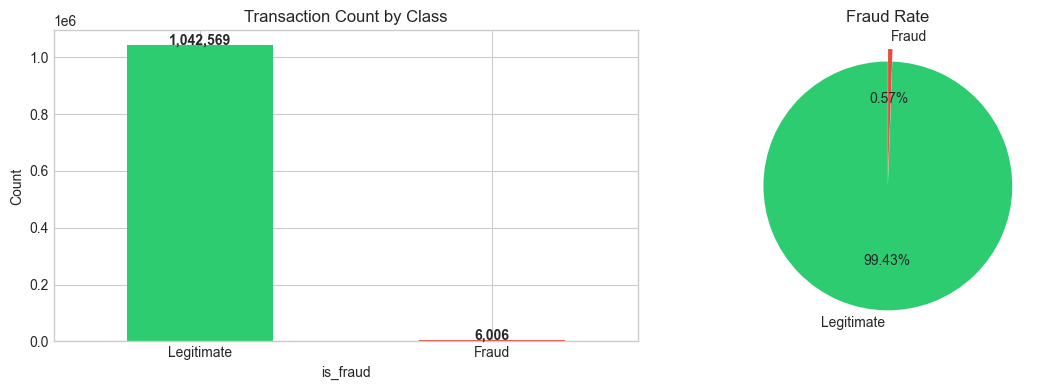

Saved: results/class_distribution.png


In [3]:
# Class distribution — the defining challenge of fraud detection
fraud_counts = df['is_fraud'].value_counts()
fraud_pct = df['is_fraud'].value_counts(normalize=True) * 100

print('=== CLASS DISTRIBUTION ===')
print(f'Legitimate: {fraud_counts[0]:,} ({fraud_pct[0]:.2f}%)')
print(f'Fraudulent: {fraud_counts[1]:,} ({fraud_pct[1]:.2f}%)')
print(f'Imbalance ratio: {fraud_counts[0] / fraud_counts[1]:.0f}:1')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fraud_counts.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Transaction Count by Class')
axes[0].set_xticklabels(['Legitimate', 'Fraud'], rotation=0)
axes[0].set_ylabel('Count')
for i, v in enumerate(fraud_counts):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(fraud_counts, labels=['Legitimate', 'Fraud'], autopct='%1.2f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90, explode=(0, 0.1))
axes[1].set_title('Fraud Rate')
plt.tight_layout()
plt.savefig('../results/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: results/class_distribution.png')

In [4]:
# Parse datetime and extract temporal features
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['dob'] = pd.to_datetime(df['dob'])
df['hour'] = df['trans_date_trans_time'].dt.hour
df['day_of_week'] = df['trans_date_trans_time'].dt.dayofweek
df['month'] = df['trans_date_trans_time'].dt.month
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
df['age'] = (df['trans_date_trans_time'] - df['dob']).dt.days / 365.25

print('Temporal features created:')
print(f'  Date range: {df["trans_date_trans_time"].min()} to {df["trans_date_trans_time"].max()}')
print(f'  Age range: {df["age"].min():.0f} to {df["age"].max():.0f} years')
print(f'  Hours: {df["hour"].min()} to {df["hour"].max()}')

Temporal features created:
  Date range: 2019-01-01 00:00:00 to 2020-03-10 16:08:00
  Age range: -57 to 44 years
  Hours: 0 to 23


## EDA: Transaction Amount Analysis
Fraud transactions often have different amount distributions — either very small (testing stolen cards)
or very large (draining the account). This is a well-documented pattern in fraud literature.

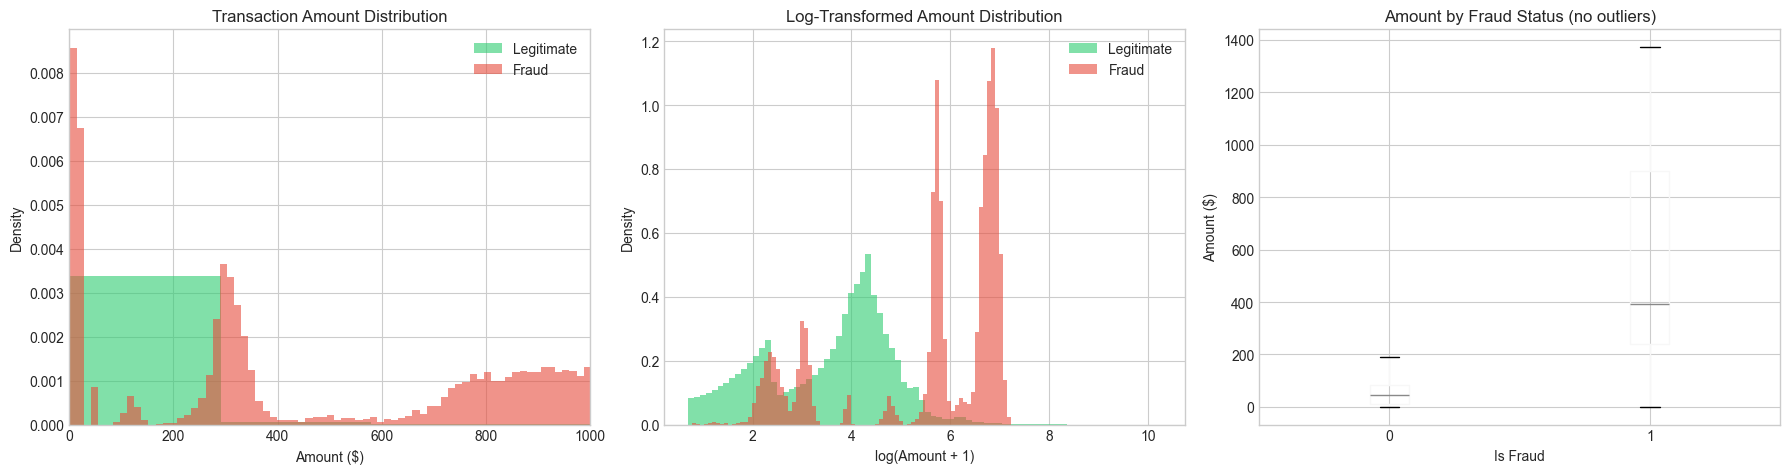

Amount statistics:
              count    mean     std   min     25%     50%     75%       max
is_fraud                                                                   
0         1042569.0   67.63  153.70  1.00    9.60   47.22   82.47  28948.90
1            6006.0  530.57  391.33  1.18  241.58  391.16  901.95   1371.81


In [5]:
# Amount distribution: fraud vs legitimate
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for label, color, name in [(0, '#2ecc71', 'Legitimate'), (1, '#e74c3c', 'Fraud')]:
    subset = df[df['is_fraud'] == label]['amt']
    axes[0].hist(subset, bins=100, alpha=0.6, color=color, label=name, density=True)
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Density')
axes[0].set_title('Transaction Amount Distribution')
axes[0].legend()
axes[0].set_xlim(0, 1000)

# Log-scale amount
for label, color, name in [(0, '#2ecc71', 'Legitimate'), (1, '#e74c3c', 'Fraud')]:
    subset = np.log1p(df[df['is_fraud'] == label]['amt'])
    axes[1].hist(subset, bins=80, alpha=0.6, color=color, label=name, density=True)
axes[1].set_xlabel('log(Amount + 1)')
axes[1].set_ylabel('Density')
axes[1].set_title('Log-Transformed Amount Distribution')
axes[1].legend()

# Box plot
df.boxplot(column='amt', by='is_fraud', ax=axes[2], showfliers=False)
axes[2].set_title('Amount by Fraud Status (no outliers)')
axes[2].set_xlabel('Is Fraud')
axes[2].set_ylabel('Amount ($)')
plt.suptitle('')

plt.tight_layout()
plt.savefig('../results/amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('Amount statistics:')
print(df.groupby('is_fraud')['amt'].describe().round(2))

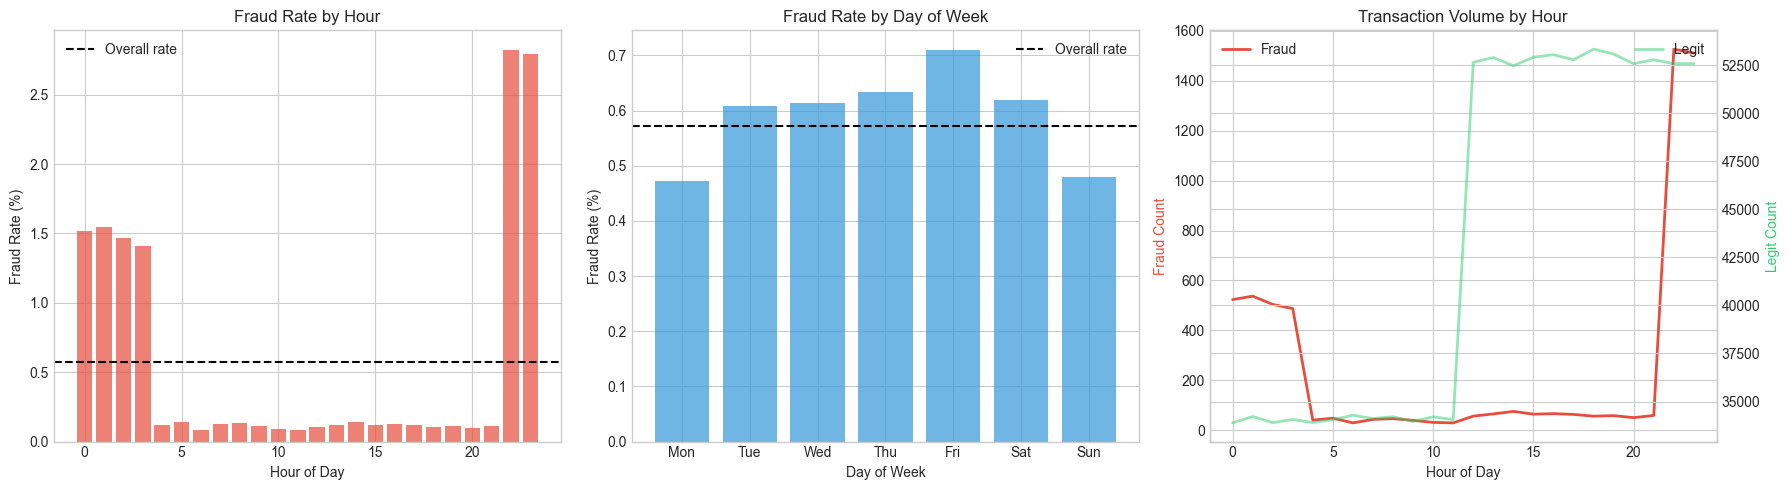

Peak fraud hour: 22 (2.82%)
Lowest fraud hour: 6 (0.08%)


In [6]:
# Temporal patterns: fraud rate by hour of day and day of week
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Fraud rate by hour
hourly_fraud = df.groupby('hour')['is_fraud'].mean() * 100
axes[0].bar(hourly_fraud.index, hourly_fraud.values, color='#e74c3c', alpha=0.7)
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Fraud Rate (%)')
axes[0].set_title('Fraud Rate by Hour')
axes[0].axhline(y=df['is_fraud'].mean()*100, color='black', linestyle='--', label='Overall rate')
axes[0].legend()

# Fraud rate by day of week
daily_fraud = df.groupby('day_of_week')['is_fraud'].mean() * 100
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[1].bar(range(7), daily_fraud.values, color='#3498db', alpha=0.7)
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(day_names)
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].set_title('Fraud Rate by Day of Week')
axes[1].axhline(y=df['is_fraud'].mean()*100, color='black', linestyle='--', label='Overall rate')
axes[1].legend()

# Transaction volume by hour (fraud vs legit)
hourly_counts = df.groupby(['hour', 'is_fraud']).size().unstack(fill_value=0)
hourly_counts[1].plot(ax=axes[2], color='#e74c3c', label='Fraud', linewidth=2)
ax2 = axes[2].twinx()
hourly_counts[0].plot(ax=ax2, color='#2ecc71', label='Legit', linewidth=2, alpha=0.5)
axes[2].set_xlabel('Hour of Day')
axes[2].set_ylabel('Fraud Count', color='#e74c3c')
ax2.set_ylabel('Legit Count', color='#2ecc71')
axes[2].set_title('Transaction Volume by Hour')
axes[2].legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.savefig('../results/temporal_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Peak fraud hour: {hourly_fraud.idxmax()} ({hourly_fraud.max():.2f}%)')
print(f'Lowest fraud hour: {hourly_fraud.idxmin()} ({hourly_fraud.min():.2f}%)')

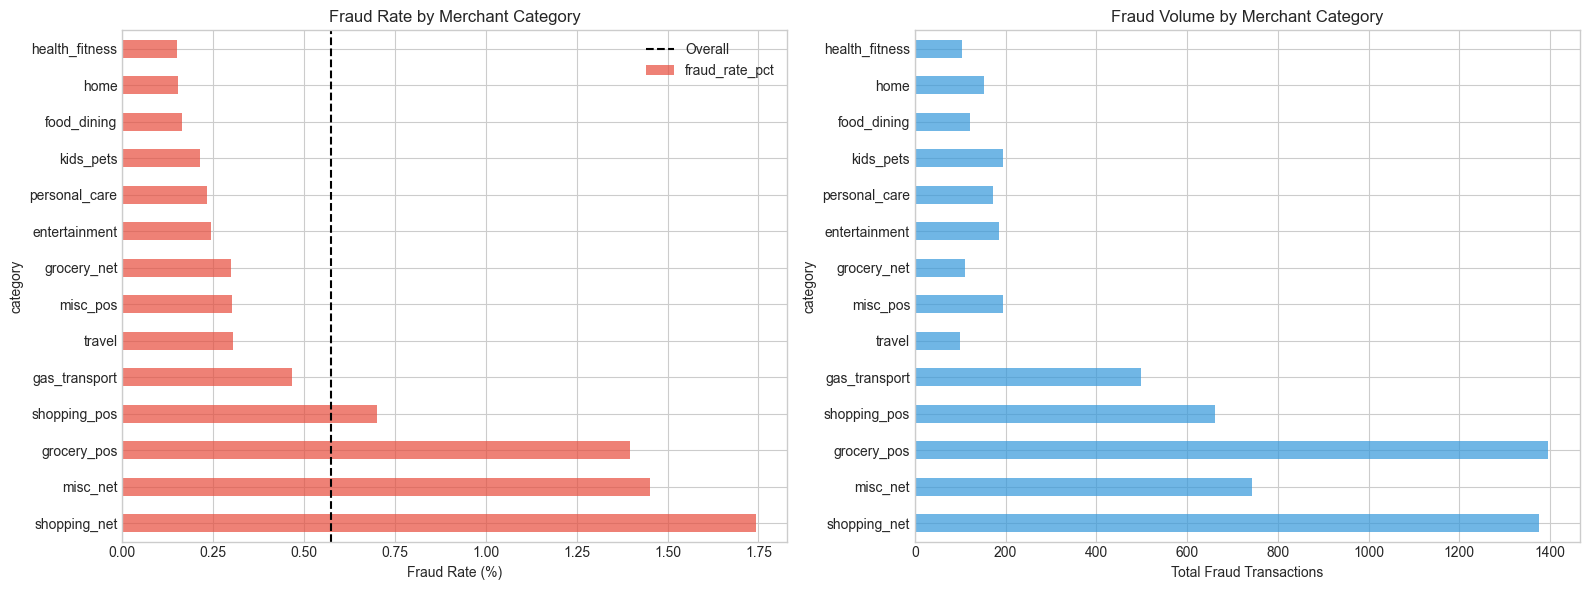

Top 5 categories by fraud rate:
                total  fraud_count  fraud_rate_pct     avg_amt
category                                                      
shopping_net    78899         1375        1.742734   88.464973
misc_net        51082          742        1.452566   81.105671
grocery_pos     99906         1396        1.397313  116.983042
shopping_pos    94353          662        0.701621   79.294910
gas_transport  106430          498        0.467913   63.421290


In [7]:
# Category analysis — which merchant categories have highest fraud rates?
cat_fraud = df.groupby('category').agg(
    total=('is_fraud', 'count'),
    fraud_count=('is_fraud', 'sum'),
    fraud_rate=('is_fraud', 'mean'),
    avg_amt=('amt', 'mean'),
    avg_fraud_amt=('amt', lambda x: df.loc[x.index[df.loc[x.index, 'is_fraud']==1], 'amt'].mean() if any(df.loc[x.index, 'is_fraud']==1) else 0)
).sort_values('fraud_rate', ascending=False)
cat_fraud['fraud_rate_pct'] = cat_fraud['fraud_rate'] * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cat_fraud['fraud_rate_pct'].plot(kind='barh', ax=axes[0], color='#e74c3c', alpha=0.7)
axes[0].set_xlabel('Fraud Rate (%)')
axes[0].set_title('Fraud Rate by Merchant Category')
axes[0].axvline(x=df['is_fraud'].mean()*100, color='black', linestyle='--', label='Overall')
axes[0].legend()

cat_fraud['fraud_count'].plot(kind='barh', ax=axes[1], color='#3498db', alpha=0.7)
axes[1].set_xlabel('Total Fraud Transactions')
axes[1].set_title('Fraud Volume by Merchant Category')

plt.tight_layout()
plt.savefig('../results/category_fraud_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 categories by fraud rate:')
print(cat_fraud[['total', 'fraud_count', 'fraud_rate_pct', 'avg_amt']].head().to_string())

Distance statistics by fraud status:
              count   mean    std   min    25%    50%    75%     max
is_fraud                                                            
0         1042569.0  76.10  29.11  0.02  55.33  78.21  98.48  152.12
1            6006.0  76.24  28.70  0.74  55.62  77.87  98.37  144.52


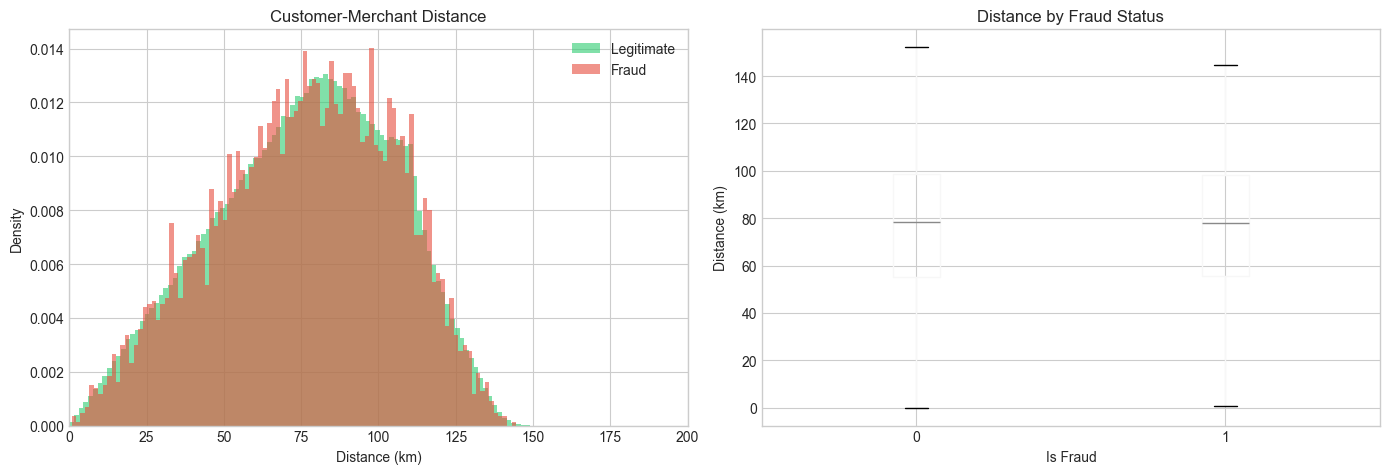

In [8]:
# Geographic analysis: distance between customer and merchant
from math import radians

def haversine_vectorized(lat1, lon1, lat2, lon2):
    """Vectorized haversine distance in km."""
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

df['distance_km'] = haversine_vectorized(
    df['lat'].values, df['long'].values,
    df['merch_lat'].values, df['merch_long'].values
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, color, name in [(0, '#2ecc71', 'Legitimate'), (1, '#e74c3c', 'Fraud')]:
    subset = df[df['is_fraud'] == label]['distance_km']
    axes[0].hist(subset, bins=100, alpha=0.6, color=color, label=name, density=True)
axes[0].set_xlabel('Distance (km)')
axes[0].set_ylabel('Density')
axes[0].set_title('Customer-Merchant Distance')
axes[0].legend()
axes[0].set_xlim(0, 200)

# Distance stats by fraud status
dist_stats = df.groupby('is_fraud')['distance_km'].describe()
print('Distance statistics by fraud status:')
print(dist_stats.round(2))

df.boxplot(column='distance_km', by='is_fraud', ax=axes[1], showfliers=False)
axes[1].set_title('Distance by Fraud Status')
axes[1].set_xlabel('Is Fraud')
axes[1].set_ylabel('Distance (km)')
plt.suptitle('')

plt.tight_layout()
plt.savefig('../results/geographic_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

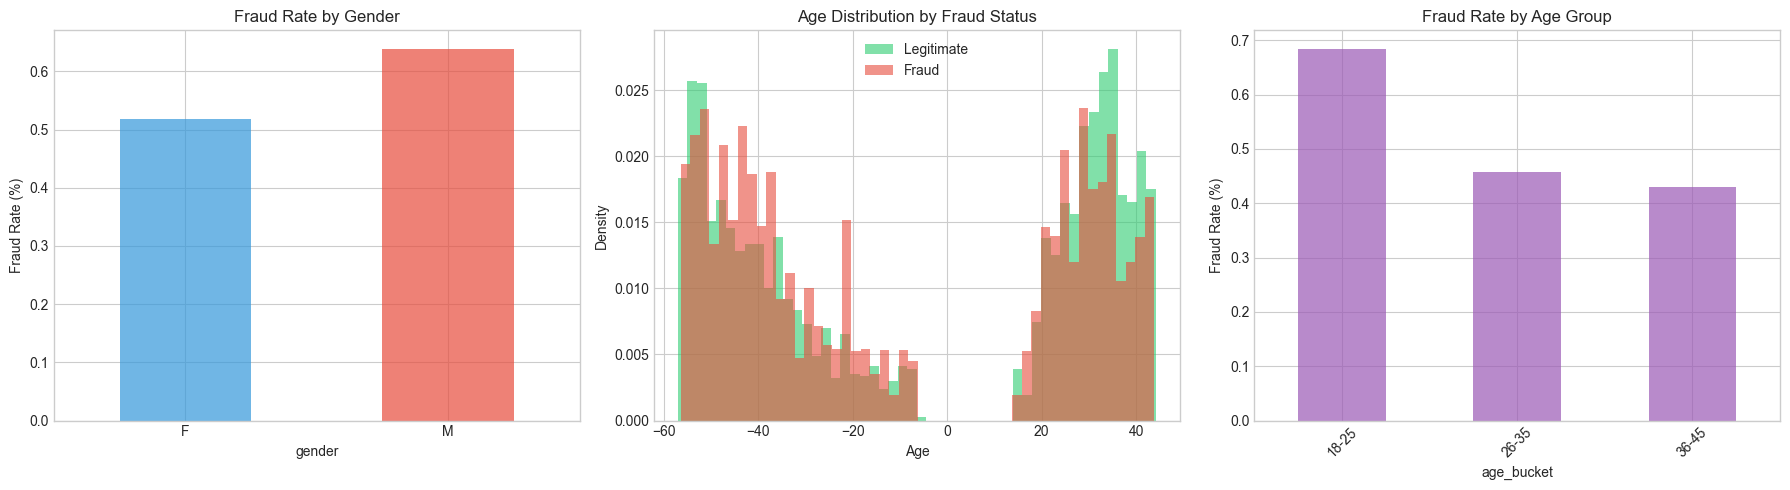

Fraud rate by gender: {'F': 0.5183215789033535, 'M': 0.6386336484712615}
Fraud rate by age group: {'18-25': 0.6837900350480269, '26-35': 0.45797768260745925, '36-45': 0.4296881455651226}


In [9]:
# Gender and age analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Fraud rate by gender
gender_fraud = df.groupby('gender')['is_fraud'].mean() * 100
gender_fraud.plot(kind='bar', ax=axes[0], color=['#3498db', '#e74c3c'], alpha=0.7)
axes[0].set_title('Fraud Rate by Gender')
axes[0].set_ylabel('Fraud Rate (%)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Age distribution by fraud
for label, color, name in [(0, '#2ecc71', 'Legitimate'), (1, '#e74c3c', 'Fraud')]:
    subset = df[df['is_fraud'] == label]['age']
    axes[1].hist(subset, bins=50, alpha=0.6, color=color, label=name, density=True)
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Density')
axes[1].set_title('Age Distribution by Fraud Status')
axes[1].legend()

# Fraud rate by age bucket
df['age_bucket'] = pd.cut(df['age'], bins=[0, 25, 35, 45, 55, 65, 100], labels=['18-25', '26-35', '36-45', '46-55', '56-65', '65+'])
age_fraud = df.groupby('age_bucket', observed=True)['is_fraud'].mean() * 100
age_fraud.plot(kind='bar', ax=axes[2], color='#9b59b6', alpha=0.7)
axes[2].set_title('Fraud Rate by Age Group')
axes[2].set_ylabel('Fraud Rate (%)')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.savefig('../results/demographics_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Fraud rate by gender: {gender_fraud.to_dict()}')
print(f'Fraud rate by age group: {age_fraud.to_dict()}')

## Domain Feature Engineering (Initial)
Before building baselines, we engineer features that fraud analysts actually use:
1. **Amount features** — log-transform, z-score within category
2. **Temporal features** — hour, day, weekend, night flag (10pm-5am)
3. **Geographic features** — customer-merchant distance
4. **Category risk** — historical fraud rate per category (leakage-safe: computed on train only)
5. **Age** — derived from DOB

In [10]:
# Build feature matrix for baselines
# Drop PII and identifier columns
drop_cols = ['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'first', 'last',
             'street', 'city', 'state', 'zip', 'dob', 'trans_num', 'job', 'age_bucket']
drop_cols = [c for c in drop_cols if c in df.columns]

df_model = df.drop(columns=drop_cols)

# Encode categoricals
df_model['gender'] = (df_model['gender'] == 'M').astype(int)

# Category encoding — label encode for now (will use target encoding in Phase 3)
le_cat = LabelEncoder()
df_model['category_encoded'] = le_cat.fit_transform(df_model['category'])
df_model = df_model.drop(columns=['category'])

# Additional features
df_model['log_amt'] = np.log1p(df_model['amt'])
df_model['is_night'] = ((df_model['hour'] >= 22) | (df_model['hour'] <= 5)).astype(int)

print(f'Feature matrix shape: {df_model.shape}')
print(f'\nFeatures ({df_model.shape[1] - 1}):')
for col in df_model.columns:
    if col != 'is_fraud':
        print(f'  {col}: {df_model[col].dtype}')

# Check for any remaining NaN
nan_counts = df_model.isna().sum()
if nan_counts.any():
    print(f'\nWARNING: NaN values found:')
    print(nan_counts[nan_counts > 0])
else:
    print(f'\nNo missing values — clean feature matrix')

Feature matrix shape: (1048575, 18)

Features (17):
  amt: float64
  gender: int64
  lat: float64
  long: float64
  city_pop: int64
  unix_time: int64
  merch_lat: float64
  merch_long: float64
  hour: int32
  day_of_week: int32
  month: int32
  is_weekend: int64
  age: float64
  distance_km: float64
  category_encoded: int64
  log_amt: float64
  is_night: int64

No missing values — clean feature matrix


In [11]:
# Train/test split — stratified to preserve fraud ratio
X = df_model.drop(columns=['is_fraud'])
y = df_model['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train set: {X_train.shape[0]:,} samples ({y_train.mean()*100:.2f}% fraud)')
print(f'Test set:  {X_test.shape[0]:,} samples ({y_test.mean()*100:.2f}% fraud)')

# Scale features for LogReg
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train set: 838,860 samples (0.57% fraud)
Test set:  209,715 samples (0.57% fraud)


## Baseline Models
We establish three baselines:
1. **Majority Class** — always predicts "legitimate" (floor)
2. **Logistic Regression (default)** — simplest ML baseline
3. **Logistic Regression (class_weight='balanced')** — cost-sensitive variant

These set the floor. Any serious model must beat all three on AUPRC.

In [12]:
def evaluate_model(model, X_test, y_test, model_name):
    """Compute all metrics for a model."""
    y_pred = model.predict(X_test)
    
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_proba = model.decision_function(X_test)
    else:
        y_proba = y_pred.astype(float)
    
    auprc = average_precision_score(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)
    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred)
    
    # Precision at 95% recall
    prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_proba)
    idx_95 = np.argmin(np.abs(rec_curve - 0.95))
    prec_at_95_recall = prec_curve[idx_95]
    
    results = {
        'model': model_name,
        'auprc': round(auprc, 4),
        'roc_auc': round(roc_auc, 4),
        'f1': round(f1, 4),
        'precision': round(precision, 4),
        'recall': round(recall, 4),
        'prec@95recall': round(prec_at_95_recall, 4)
    }
    return results, y_pred, y_proba

all_results = []
print('Evaluation function ready')

Evaluation function ready


In [13]:
# Baseline 1: Majority Class Classifier
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train_scaled, y_train)
res_dummy, _, _ = evaluate_model(dummy, X_test_scaled, y_test, 'Majority Class')
all_results.append(res_dummy)
print(f'Majority Class: AUPRC={res_dummy["auprc"]}, F1={res_dummy["f1"]}, ROC-AUC={res_dummy["roc_auc"]}')

Majority Class: AUPRC=0.0057, F1=0.0, ROC-AUC=0.5


In [14]:
# Baseline 2: Logistic Regression (default)
lr_default = LogisticRegression(max_iter=1000, random_state=42)
lr_default.fit(X_train_scaled, y_train)
res_lr, y_pred_lr, y_proba_lr = evaluate_model(lr_default, X_test_scaled, y_test, 'LogReg (default)')
all_results.append(res_lr)
print(f'LogReg (default): AUPRC={res_lr["auprc"]}, F1={res_lr["f1"]}, ROC-AUC={res_lr["roc_auc"]}')

print('\nClassification Report:')
print(classification_report(y_test, y_pred_lr, target_names=['Legitimate', 'Fraud']))

LogReg (default): AUPRC=0.3622, F1=0.1653, ROC-AUC=0.8845

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.99      1.00      1.00    208514
       Fraud       0.68      0.09      0.17      1201

    accuracy                           0.99    209715
   macro avg       0.84      0.55      0.58    209715
weighted avg       0.99      0.99      0.99    209715



In [15]:
# Baseline 3: Logistic Regression (class_weight='balanced') — cost-sensitive
lr_balanced = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_balanced.fit(X_train_scaled, y_train)
res_lr_bal, y_pred_lr_bal, y_proba_lr_bal = evaluate_model(
    lr_balanced, X_test_scaled, y_test, 'LogReg (balanced)'
)
all_results.append(res_lr_bal)
print(f'LogReg (balanced): AUPRC={res_lr_bal["auprc"]}, F1={res_lr_bal["f1"]}, ROC-AUC={res_lr_bal["roc_auc"]}')

print('\nClassification Report:')
print(classification_report(y_test, y_pred_lr_bal, target_names=['Legitimate', 'Fraud']))

LogReg (balanced): AUPRC=0.2484, F1=0.0768, ROC-AUC=0.9411

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      0.88      0.94    208514
       Fraud       0.04      0.85      0.08      1201

    accuracy                           0.88    209715
   macro avg       0.52      0.87      0.51    209715
weighted avg       0.99      0.88      0.93    209715



In [16]:
# Quick XGBoost baseline (preview of Phase 2 champion)
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight: {scale_pos_weight:.1f}')

xgb_base = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='aucpr',
    n_jobs=-1,
    verbosity=0
)
xgb_base.fit(X_train, y_train)
res_xgb, y_pred_xgb, y_proba_xgb = evaluate_model(xgb_base, X_test, y_test, 'XGBoost (baseline)')
all_results.append(res_xgb)
print(f'XGBoost (baseline): AUPRC={res_xgb["auprc"]}, F1={res_xgb["f1"]}, ROC-AUC={res_xgb["roc_auc"]}')

print('\nClassification Report:')
print(classification_report(y_test, y_pred_xgb, target_names=['Legitimate', 'Fraud']))

scale_pos_weight: 173.6


XGBoost (baseline): AUPRC=0.9314, F1=0.5563, ROC-AUC=0.9986

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      1.00    208514
       Fraud       0.39      0.96      0.56      1201

    accuracy                           0.99    209715
   macro avg       0.70      0.98      0.78    209715
weighted avg       1.00      0.99      0.99    209715



In [17]:
# Head-to-head comparison table
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values('auprc', ascending=False).reset_index(drop=True)
results_df.index = results_df.index + 1
results_df.index.name = 'Rank'

print('=' * 90)
print('PHASE 1 BASELINE COMPARISON (ranked by AUPRC)')
print('=' * 90)
print(results_df.to_string())
print('=' * 90)

PHASE 1 BASELINE COMPARISON (ranked by AUPRC)
                   model   auprc  roc_auc      f1  precision  recall  prec@95recall
Rank                                                                               
1     XGBoost (baseline)  0.9314   0.9986  0.5563     0.3916  0.9600         0.5009
2       LogReg (default)  0.3622   0.8845  0.1653     0.6807  0.0941         0.0086
3      LogReg (balanced)  0.2484   0.9411  0.0768     0.0402  0.8468         0.0192
4         Majority Class  0.0057   0.5000  0.0000     0.0000  0.0000         0.0057


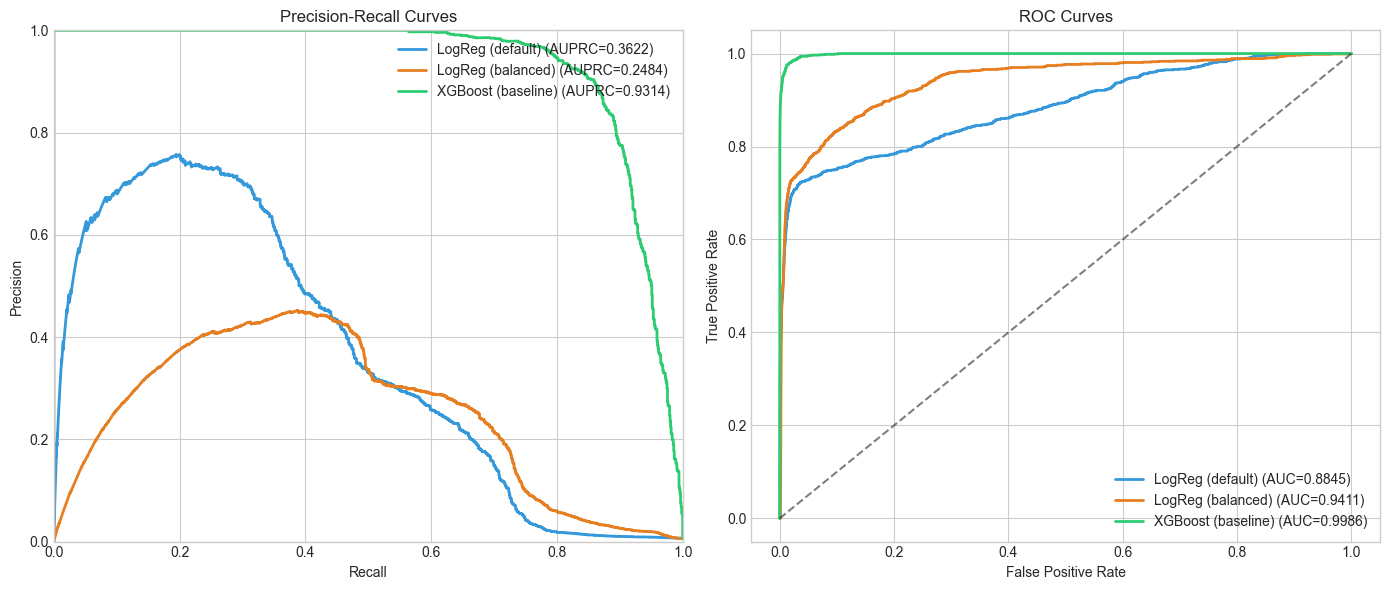

In [18]:
# PR curves and ROC curves for all models
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

models_for_curves = [
    ('LogReg (default)', y_proba_lr),
    ('LogReg (balanced)', y_proba_lr_bal),
    ('XGBoost (baseline)', y_proba_xgb)
]

colors = ['#3498db', '#e67e22', '#2ecc71']
for (name, y_proba), color in zip(models_for_curves, colors):
    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    axes[0].plot(rec, prec, label=f'{name} (AUPRC={ap:.4f})', color=color, linewidth=2)

axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curves')
axes[0].legend(loc='upper right')
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1])

from sklearn.metrics import roc_curve
for (name, y_proba), color in zip(models_for_curves, colors):
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_val = roc_auc_score(y_test, y_proba)
    axes[1].plot(fpr, tpr, label=f'{name} (AUC={auc_val:.4f})', color=color, linewidth=2)

axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.savefig('../results/baseline_curves.png', dpi=150, bbox_inches='tight')
plt.show()

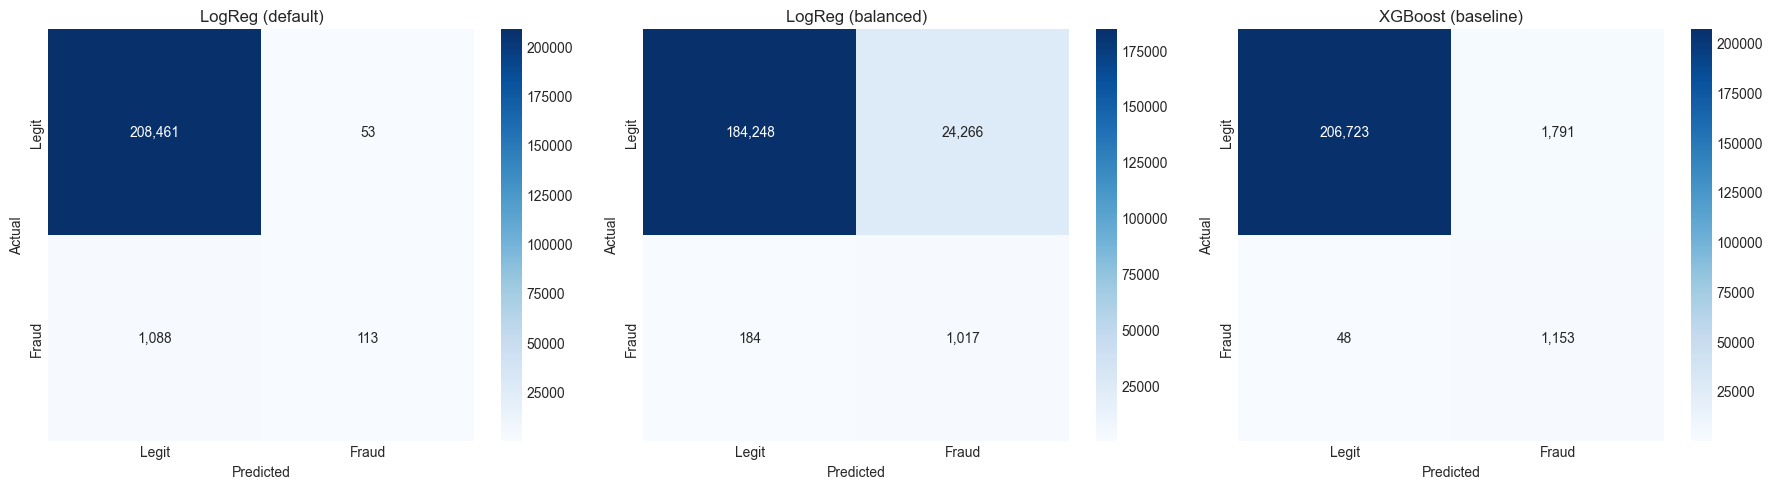

In [19]:
# Confusion matrices for best baseline
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, y_pred) in zip(axes, [
    ('LogReg (default)', y_pred_lr),
    ('LogReg (balanced)', y_pred_lr_bal),
    ('XGBoost (baseline)', y_pred_xgb)
]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=ax,
                xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('../results/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

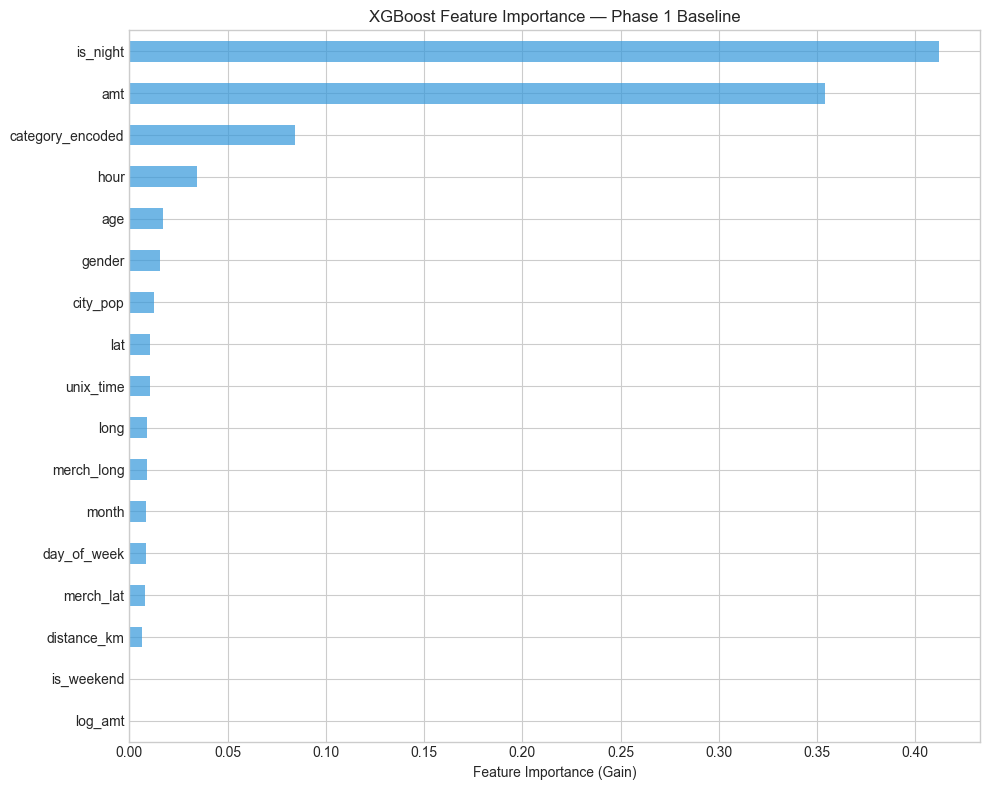

Top 5 features:
  age: 0.0169
  hour: 0.0343
  category_encoded: 0.0842
  amt: 0.3539
  is_night: 0.4123


In [20]:
# XGBoost feature importance (quick look)
importance = pd.Series(
    xgb_base.feature_importances_, index=X_train.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
importance.plot(kind='barh', ax=ax, color='#3498db', alpha=0.7)
ax.set_xlabel('Feature Importance (Gain)')
ax.set_title('XGBoost Feature Importance — Phase 1 Baseline')
plt.tight_layout()
plt.savefig('../results/feature_importance_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 features:')
for feat, imp in importance.tail(5).items():
    print(f'  {feat}: {imp:.4f}')

In [21]:
# Save all metrics
metrics = {
    'phase': 1,
    'date': '2026-04-27',
    'primary_metric': 'AUPRC',
    'dataset': {
        'name': 'Credit Card Transactions Fraud Detection (Sparkov/Kartik2112)',
        'source': 'huggingface:santosh3110/credit_card_fraud_transactions',
        'total_samples': len(df),
        'features': len(X.columns),
        'fraud_rate': round(df['is_fraud'].mean(), 4),
        'train_size': len(X_train),
        'test_size': len(X_test)
    },
    'baselines': all_results
}

with open('../results/metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print('Metrics saved to results/metrics.json')
print(f'\n=== PHASE 1 SUMMARY ===')
print(f'Dataset: {len(df):,} transactions, {df["is_fraud"].sum():,} fraud ({df["is_fraud"].mean()*100:.2f}%)')
print(f'Features: {len(X.columns)} (with initial domain engineering)')
print(f'Best baseline: {results_df.iloc[0]["model"]} with AUPRC={results_df.iloc[0]["auprc"]}')
print(f'\nNext: Phase 2 will compare 6+ models including RF, LightGBM, CatBoost, IsolationForest')

Metrics saved to results/metrics.json

=== PHASE 1 SUMMARY ===
Dataset: 1,048,575 transactions, 6,006 fraud (0.57%)
Features: 17 (with initial domain engineering)
Best baseline: XGBoost (baseline) with AUPRC=0.9314

Next: Phase 2 will compare 6+ models including RF, LightGBM, CatBoost, IsolationForest
